In [1]:
!pip install pandas numpy scikit-learn

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pyreadstat

# Load the dataset from the Stata file using pyreadstat
df, meta = pyreadstat.read_dta("../data/raw/cdi_household_clean_nopii.dta")

# Print the dataset shape and first few rows to inspect
print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (1505, 9565)
   duration  region  district   vill    village community_type restore_check  \
0      7452       5        51  51024  Koitienko        RESTORE             1   
1      5408       4        41  41011     KLODIO     COMPARISON           NaN   
2      6208       5        51  51028   Ananguié        RESTORE             0   
3      3228       7        74  74003    BOHOUIN     COMPARISON           NaN   
4      8314       4        41  41011     KLODIO     COMPARISON           NaN   

  hhid_restore village_restore gender_restore  ... cocoa_sell_kg  \
0            0                                 ...        1105.0   
1          NaN                                 ...           NaN   
2          NaN                                 ...         212.5   
3          NaN                                 ...           NaN   
4          NaN                                 ...           NaN   

  cocoa_price_kg farm_a_1_acres farm_a_2_acres  farm_a_3_acres  \
0      11.764706

In [7]:
# Separate predictors and target
X = df.drop(columns=[target])
y = df[target]

# Identify and process non-numeric (object) columns
non_numeric_cols = X.select_dtypes(include=['object']).columns
print("Non-numeric columns:", list(non_numeric_cols))

from sklearn.preprocessing import LabelEncoder
for col in non_numeric_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Identify datetime columns and convert them to numeric (e.g., nanosecond timestamps)
datetime_cols = X.select_dtypes(include=['datetime64[ns]', 'datetime64[ns, UTC]']).columns
print("Datetime columns:", list(datetime_cols))

for col in datetime_cols:
    X[col] = X[col].astype('int64')

# Now standardize the predictors (Lasso is sensitive to scale)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled features shape:", X_scaled.shape)


Non-numeric columns: ['village', 'community_type', 'restore_check', 'hhid_restore', 'village_restore', 'gender_restore', 'sample_restore', 'confirm_restore', 'hhid_nonrestore', 'hhid', 'audio_audit', 'nothead', 'nothead_oth', 'ethnicity_oth', 'language_oth', 'religion', 'lead_vill', 'lead_villo', 'prim_fem_yn', 'hhgroup_m18', 'hhgroup_f18', 'hhgroup_m17', 'hhgroup_f17', 'hh_relate_oth_1', 'ethnicity_head_1', 'ethnicity_head_oth_1', 'hhmem_married_1', 'hhmem_edu_level_1', 'hhmem_edu_levelo_1', 'hhmem_edu_attend_1', 'hhmem_edu_whyno_1', 'hhmem_edu_whyno_1_1', 'hhmem_edu_whyno_2_1', 'hhmem_edu_whyno_3_1', 'hhmem_edu_whyno_4_1', 'hhmem_edu_whyno_5_1', 'hhmem_edu_whyno_6_1', 'hhmem_edu_whyno_7_1', 'hhmem_edu_whyno_8_1', 'hhmem_edu_whyno_9_1', 'hhmem_edu_whyno_10_1', 'hhmem_edu_whyno_11_1', 'hhmem_edu_whyno_12_1', 'hhmem_edu_whyno_13_1', 'hhmem_edu_whyno_14_1', 'hhmem_edu_whyno_15_1', 'hhmem_edu_whyno_16_1', 'hhmem_edu_whyno_17_1', 'hhmem_edu_whyno_18_1', 'hhmem_edu_whyno_19_1', 'hhmem_edu_w

In [11]:
from sklearn.impute import SimpleImputer

# Impute missing values using the mean (or you could choose 'median', etc.)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_scaled)

print("After imputation, shape:", X_imputed.shape)

# Now fit LassoCV with the imputed data
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(cv=5, random_state=1, n_jobs=-1, max_iter=10000)
lasso_cv.fit(X_imputed, y)

print("Best alpha:", lasso_cv.alpha_)


After imputation, shape: (1505, 9564)
Best alpha: 196.8891961041573


In [12]:
# Create a Series of coefficients indexed by feature names.
coefs = pd.Series(lasso_cv.coef_, index=X.columns)

# Filter for non-zero coefficients (i.e., features selected by Lasso)
selected_features = coefs[coefs != 0]
print("Number of selected features:", selected_features.shape[0])

# Display the top 10 features by absolute coefficient value
top_features = selected_features.reindex(selected_features.abs().sort_values(ascending=False).index)
print("Top 10 Selected Features:")
print(top_features.head(10))


Number of selected features: 1
Top 10 Selected Features:
cocoa_produce_tot    1192.12516
dtype: float64


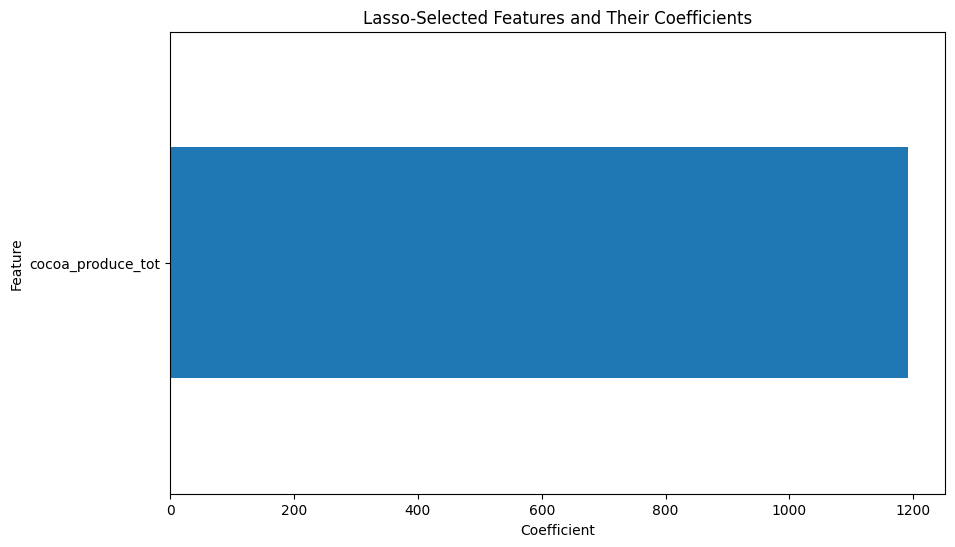

In [14]:
plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh')
plt.title('Lasso-Selected Features and Their Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.show()
